# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [1]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json

from langchain_core.messages import HumanMessage

from network_manager_agent import (
    LLMConfig,
    build_agent,
    create_llm,
)
from network_manager_agent.data import DataManager

## Load and Pre-compute Data: Filter & Aggregate (done by DataManager)

In [2]:
county_specialty_thresholds = {
    "mi": {
        "wayne": {"general practice": 10.0, "cardiology": 15.0},
        "washtenaw": {"general practice": 10.0, "cardiology": 15.0},
    }
}

dm = DataManager(county_specialty_thresholds=county_specialty_thresholds)
candidates = dm.get_candidates_df()
members = dm.get_members_df()

print(f"Loaded {len(candidates)} candidates, {len(members)} members")

Loaded 85615 candidates, 12051 members


## Create LLM

In [3]:
llm_config = LLMConfig(base_url="http://localhost:8080/v1")
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")

In [7]:
content = response.content.strip()
print(f"LLM response: {content}")

LLM response: Hey there! 👋 Yep, I'm up and running and ready to help. What can I do for you today?


In [9]:
reasoning = response.additional_kwargs.get("reasoning_content", "No reasoning provided")
print(f"LLM reasoning: {reasoning}")

LLM reasoning: Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hey there! Just making sure you're up and running!"
   - Tone: Friendly, casual, checking system status
   - Intent: Confirm I'm operational and ready to help

2.  **Identify Key Requirements:**
   - Acknowledge the greeting
   - Confirm operational status
   - Maintain friendly, conversational tone
   - Offer assistance

3.  **Formulate Response (Mental):**
   - "Hey! Yep, I'm up and running and ready to help. What can I do for you today?"
   - Check tone: Friendly, matches user's casual style
   - Check content: Confirms status, invites next step
   - Keep it concise

4.  **Refine Response:**
   - "Hey there! 👋 Yep, I’m up and running and ready to help. What’s on your mind today?"
   - Adds a friendly emoji (optional but fits casual tone)
   - Clear, direct, and open-ended

5.  **Final Output Generation:** (matches refined version)✅
   - No complex reasoning needed, just a straightforward acknowle

## Build Agent

In [4]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = str(Path.cwd().parent / "checkpoints.sqlite")
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = build_agent(llm, checkpointer=checkpointer)
print("Agent built successfully!")


Agent built successfully!


## Visualize Graph

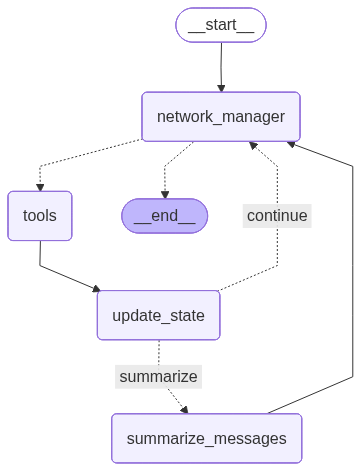

In [5]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Run the Agent

In [6]:
from network_manager_agent.ui import run_agent


def run_agent_demo(agent, inputs: dict, config: dict):
    """Wrapper for run_agent that matches the notebook's naming convention."""
    run_agent(agent, inputs, config)


In [7]:
# Create a thread
config = {"configurable": {"thread_id": "test3"}}


In [8]:
# Specify an input
messages = [HumanMessage(content='''
Find the entities that have providers in all the specialties in our network scope. Then show me top 5 largest by provider count, in table format.
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL: run_code ---
    # Derive required specialties from thresholds
    required_specs = set()
    for state_val, counties in thresholds.items():
        for county_val, specs in counties.items():
            required_specs.update(specs.keys())
    
    print(f"Required specialties: {required_specs}")
    
    # Find entities and their specialties
    entity_specs = candidates_df.groupby("entity")["specialty"].apply(
        lambda x: set(x.str.lower().unique()))
    
    # Filter entities that have ALL required specialties
    candidate_entities = entity_specs[entity_specs.apply(lambda s: required_specs.issubset(s))].index.tolist()
    
    print(f"Number of entities with all required specialties: {len(candidate_entities)}")
    
    # Get provider counts for these entities
    entity_provider_counts = candidates_df[candidates_df["entity"].isin(candidate_entities)].groupby("entity").size().reset_index(name="pro

In [9]:
# Specify an input
messages = [HumanMessage(content='''
For these top 5, show me the number of providers they have for the particular specialties in our network scope. Again, in table format.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL: run_code ---
    top_5_entities = ['mymichigan health', 'corewell health', 'henry ford health', 'trinity health', 'vamc (all)']
    
    # Filter candidates for these entities
    filtered = candidates_df[candidates_df['entity'].str.lower().isin(top_5_entities)]
    
    # Group by entity and specialty, count providers
    spec_counts = filtered.groupby(['entity', 'specialty']).size().reset_index(name='provider_count')
    
    # Pivot to show specialties as columns
    pivot = spec_counts.pivot(index='entity', columns='specialty', values='provider_count').reset_index()
    
    # Reorder columns to show entity first, then general practice, then cardiology
    pivot = pivot.rename(columns={'entity': 'Entity'})
    if 'general practice' in pivot.columns and 'cardiology' in pivot.columns:
        pivot = pivot[['Entity', 'general practice', 'cardiology']]
    else:
        # Handle case sensitivity issues
   

In [10]:
# Specify an input
messages = [HumanMessage(content='''
Now, rank these 5 by the coverage they would provide to the network if they were added. Show results in table format.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL: run_code ---
    top_5_entities = ['mymichigan health', 'corewell health', 'henry ford health', 'trinity health', 'vamc (all)']
    
    # Get baseline coverage
    base_cov, _ = compute_coverage(network_df, members_df, thresholds, candidates_df)
    base_df = pd.DataFrame(base_cov)
    
    # Create a dictionary to store baseline coverage by (county, specialty)
    base_dict = {}
    for row in base_cov:
        key = (row['county'].lower(), row['specialty'].lower())
        base_dict[key] = row['coverage_percentage']
    
    # For each entity, simulate adding it and calculate the new coverage
    rankings = []
    for ent in top_5_entities:
        # Get providers for this entity
        ent_providers = candidates_df[candidates_df['entity'].str.lower() == ent.lower()]
        
        # Simulate network with this entity added
        sim_net = pd.concat([network_df, ent_providers])
        
        # Com

## Inspect Agent State

In [11]:
# Show the last human message from the conversation
state = agent.get_state(config)
messages = state.values.get("messages", [])
last_human = [m for m in reversed(messages) if m.type == 'human']
print("Last human message:")
print(last_human[0].content if last_human else "(none)")


Last human message:

Now, rank these 5 by the coverage they would provide to the network if they were added. Show results in table format.



In [12]:
print("Summary:")
print(state.values.get("summary", "(empty)"))

print()

print("Schema profile:")
schema = state.values.get("schema_profile", "")
print(f"  {len(schema)} chars" if schema else "  (empty)")


Summary:
Objective: Find the entities that have providers in all the specialties in our network scope. Then show me top 5 largest by provider count, in table format. For these top 5, show me the number of providers they have for the particular specialties in our network scope. Again, in table format.

Progress: Called `stdout` to identify required specialties and filter entities covering all specialties. Retrieved the top 5 entities ranked by total provider count. Called `stdout` again to obtain provider counts per specialty for the top 5 entities.

Key Findings:
- Required Specialties: General Practice, Cardiology.
- Total entities with all required specialties: 47.
- Top 5 Entities by Provider Count:
  1. MyMichigan Health: 8,684 providers (General Practice: 19, Cardiology: 622).
  2. Corewell Health: 8,506 providers (General Practice: 20, Cardiology: 953).
  3. Henry Ford Health: 5,135 providers (General Practice: 12, Cardiology: 367).
  4. Trinity Health: 3,890 providers (General P

In [13]:
import pandas as pd
print("Current network (list of entity IDs):")
network = agent.get_state(config).values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty - no entities added yet)")


Current network (list of entity IDs):
  (empty - no entities added yet)


## Try a More Complex Prompt

In [14]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
OK, now I'd like to add one more contract entity to the network. But I'd like to make sure this one has high effectiveness, but also one that best adds to the coverage. Find one, add it, and then report back on the status of the network.
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
}

# run_agent_demo(agent, inputs, config)


In [15]:
# # Check final state
# state = agent.get_state(config)
# print("Summary:")
# print(state.values.get("summary", "(empty)"))

# print("\nNetwork (entity IDs):")
# network = state.values.get("network", [])
# if network:
#     for i, entity_id in enumerate(network, 1):
#         print(f"  {i}. {entity_id}")
# else:
#     print("  (empty)")
